<a href="https://colab.research.google.com/github/ryueuitae-blip/AIEYES-STUDY/blob/euitae-branch/%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%85%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
# 4가지 파이썬 라이브러리 불러오기
import pandas as pd # pandas: 데이터 분석 활용
import numpy as np # numpy: 계산,연산
import matplotlib.pyplot as plt # matplotlib.pyplot: 2D그래프
import seaborn as sns #seaborn: 데이터 시각화 라이브러리

In [40]:
#df = sns.load_dataset('titanic') # seaborn 데이터는 정제되어 있음
#print(df.info())

In [41]:
#from sklearn.datasets import fetch_openml

# 원본에 가장 가까운 타이타닉 데이터셋 불러오기
#titanic_raw = fetch_openml('titanic', version=1, as_frame=True)
#df = titanic_raw.frame

#print(df.info())

In [42]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# 1. 1309개 전체 데이터를 불러옵니다.
titanic_raw = fetch_openml('titanic', version=1, as_frame=True)
df = titanic_raw.frame

# 2. 7:3 비율(test_size=0.3)로 나눕니다.
# 1309 * 0.7 ≒ 916 / 1309 * 0.3 ≒ 393
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

# 3. 개수 확인
print(f"학습용(df_train): {len(df_train)}개")
print(f"테스트용(df_test): {len(df_test)}개")

# 인덱스가 뒤죽박죽인 게 보기 싫다면 깔끔하게 정리!
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.head(5)

학습용(df_train): 916개
테스트용(df_test): 393개


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,3,0,"Smiljanic, Mr. Mile",male,NaN,0,0,315037,8.6625,NaN,S,NaN,NaN,NaN
1,3,0,"Bostandyeff, Mr. Guentcho",male,26.0,0,0,349224,7.8958,NaN,S,NaN,NaN,"Bulgaria Chicago, IL"
2,2,1,"Phillips, Miss. Kate Florence ('Mrs Kate Louis...",female,19.0,0,0,250655,26.0000,NaN,S,11,NaN,"Worcester, England"
3,3,0,"Sage, Miss. Dorothy Edith 'Dolly'",female,NaN,8,2,CA. 2343,69.5500,NaN,S,NaN,NaN,NaN
4,3,0,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,NaN,NaN,NaN


In [43]:
print(df_train.info())
print("---------------------")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     916 non-null    int64   
 1   survived   916 non-null    category
 2   name       916 non-null    object  
 3   sex        916 non-null    category
 4   age        729 non-null    float64 
 5   sibsp      916 non-null    int64   
 6   parch      916 non-null    int64   
 7   ticket     916 non-null    object  
 8   fare       915 non-null    float64 
 9   cabin      204 non-null    object  
 10  embarked   915 non-null    category
 11  boat       327 non-null    object  
 12  body       85 non-null     float64 
 13  home.dest  510 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 81.9+ KB
None
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 14 columns):
 #   Column     Non-Null Count 

In [44]:
# 불필요한 피처 제거
# 데이터셋에서 name, ticket, body, cabin, home.dest 피처 제거
columns_to_drop = ['name', 'ticket', 'body', 'cabin', 'home.dest']

# df_train에서 존재하는 열만 제거
existing_columns_train = [col for col in columns_to_drop if col in df_train.columns]
if existing_columns_train:
    df_train = df_train.drop(existing_columns_train, axis=1)

# df_test에서 존재하는 열만 제거
existing_columns_test = [col for col in columns_to_drop if col in df_test.columns]
if existing_columns_test:
    df_test = df_test.drop(existing_columns_test, axis=1)

In [45]:
print(df_train.info())
print("---------------------")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    916 non-null    int64   
 1   survived  916 non-null    category
 2   sex       916 non-null    category
 3   age       729 non-null    float64 
 4   sibsp     916 non-null    int64   
 5   parch     916 non-null    int64   
 6   fare      915 non-null    float64 
 7   embarked  915 non-null    category
 8   boat      327 non-null    object  
dtypes: category(3), float64(2), int64(3), object(1)
memory usage: 46.1+ KB
None
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    393 non-null    int64   
 1   survived  393 non-null    category
 2   sex       393 non-null    category
 3   age       317 non-null    float64 
 4   sibs

survived
0    585
1    331
Name: count, dtype: int64


<Axes: xlabel='survived'>

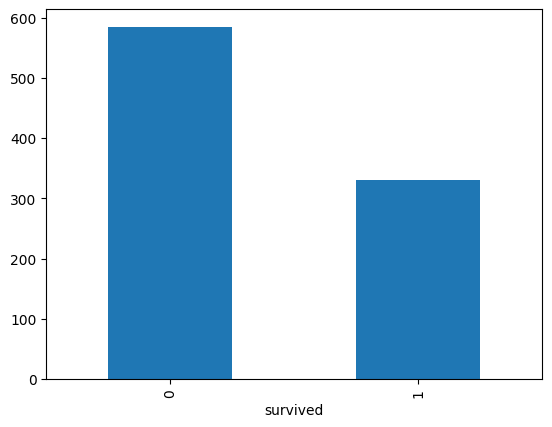

In [46]:
# 탐색적 데이터 분석
print(df_train['survived'].value_counts()) # 고유 값 세기
df_train['survived'].value_counts().plot.bar() # 막대 그래프

pclass
3    507
1    227
2    182
Name: count, dtype: int64


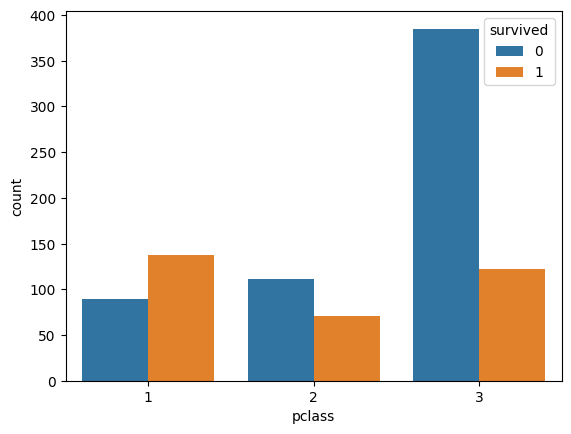

In [47]:
# 생존 여부로 그룹 나누기
print(df_train['pclass'].value_counts())
ax = sns.countplot(x='pclass', hue='survived', data=df_train)
#

In [49]:
from scipy import stats
# 두 집단 피처 비교,탐색 자동화 하는 함수 정의
def valid_features(df, col_name, distribution_check=True):
    # 두 집단 생존 여부 분포 그래프 출력
    g = sns.FacetGrid(df, col='survived')
    g.map(plt.hist, col_name, bins= 30)

    # 두 집단 표편 출력
    titanic_survived = df[df['survived']==1]
    titanic_survived_static = np.array(titanic_survived[col_name])
    print("data std is", '%.2f' % np.std(titanic_survived_static))
    titanic_survived = df[df['survived']==0]
    titanic_survived_static = np.array(titanic_survived[col_name])
    print("data std is", '%.2f' % np.std(titanic_survived_static))

    # T-test로 두 집단 평균 차이 검정

    tTestResult = stats.ttest_indtitanic_survived[col_name], titanic_n_survived[col_name])
    tTestResultDiffvar = stats.ttest_ind(titanic_survived[col_name],titanic_n_survived[col_name]